# COGS 108 - EDA Checkpoint

## Authors

- Nicholas Campos: Conceptualization, Methodology, Writing – original draft

- Lui Gazem: Analysis, Writing – original draft

- Cadence Eastep: Background research, Writing – original draft, Writing – review & editing

- Ahgean Davis: Data curation, Software, Visualization

- Chuck Davies: Project administration, Ethics review, Writing – review & editing


**Primary research question:**  
How do daily COVID-19 case counts vary by day of the week at the county level, and how are these variations associated with mobility patterns (workplace, residential, retail & recreation, and transit mobility)?

**Secondary (backup) research question:**  
To what extent are changes in workplace and residential mobility associated with subsequent changes in daily COVID-19 case counts over time at the county level?

**Variables and controls:**
- **Dependent variable (DV):** daily new COVID-19 case counts (county-day level)
- **Independent variables (IVs):** workplace mobility, residential mobility, retail & recreation mobility, transit mobility, day of week
- **Controls:** county fixed effects, time (date or week index), population (if available), lagged case counts

**Note:** We discussed our primary research question with the TA, who indicated it was appropriate but recommended including a backup question in case broader scope is needed after exploratory data analysis. Both questions use the same county-level COVID-19 and mobility dataset.

## Background and Prior Work

Mobility rates and COVID-19 case counts exhibited a substantial correlation throughout the pandemic. In response to the rapid spread of the virus, public health authorities urged individuals to remain at home whenever possible, recognizing that increased movement and social interaction heightened the risk of transmission. From the onset of this global crisis, policymakers closely monitored the relationship between population mobility and infection rates in an effort to mitigate uncontrolled surges in cases. A study conducted by the Centers for Disease Control and Prevention (CDC) examined anonymized cell phone GPS data to assess patterns of movement across counties in the United States. The researchers observed that reductions in trips outside the home were associated with subsequent declines in reported COVID-19 cases. Specifically, changes in mobility were analyzed in relation to new case counts approximately 11 days later, reflecting the typical incubation period and reporting delays. The study also compared urban and rural areas to determine whether mobility patterns affected transmission differently across settings. This distinction was critical, as urban centers tend to be more densely populated, exhibit distinct transportation behaviors, and may experience differing timelines of viral introduction and spread compared to rural communities.

For our project, we aim to more closely examine variation in COVID-19 case counts across days of the week, with particular attention to identifying when case spikes are most pronounced. Consistent with our hypothesis, we anticipate that reported cases will be higher during weekdays compared to weekends. One possible explanation is that essential workers continued in-person employment throughout much of the pandemic, increasing opportunities for exposure during the workweek. Workplace environments may facilitate transmission due to repeated close interactions with coworkers and contact with shared surfaces (e.g., counters, equipment, communal appliances). These routine occupational exposures could contribute to elevated transmission risk during weekdays, which may subsequently be reflected in higher reported case counts. This hypothesis is supported by prior empirical work conducted by Hannah Hoffman and The COVID Tracking Project, which examined temporal reporting patterns in state-level COVID-19 case data. Their analysis demonstrated a consistent decline in reported case counts over weekends. Importantly, this pattern was attributed not only to behavioral changes but also to structural factors, including reduced testing, reporting delays, and public health regulations that limited activity during weekends in many states at the time.

In a study conducted by Bulut Boru and M. Emre Gursoy, the authors developed a computational model designed to identify and learn patterns between human mobility and subsequent COVID-19 case counts. Their approach dynamically selects the optimal time frame and predictive method to enhance accuracy. When evaluated across 13 countries, the model demonstrated a high degree of precision in forecasting daily COVID-19 cases. The study further revealed a strong correlation between the movement patterns of individuals and the spread of the virus within their communities. Findings of this nature underscore the substantial impact that human mobility can have on disease transmission, providing empirical justification for the strict travel restrictions and mobility-limiting policies implemented by governments worldwide during the pandemic.


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Hypothesis


We hypothesize that daily COVID-19 case counts (daily_cases) will vary systematically across days of the week, with lower reported cases on weekends (is_weekend = 1) and higher reported cases during weekdays. Additionally, we predict that increases in workplace mobility (workplaces) will be positively associated with daily COVID-19 case counts, while increases in residential mobility (residential) will be negatively associated with daily case counts at the county level over time.


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [32]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                           

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00, 14.56it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [34]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [35]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

In this section, we explore patterns in county-level COVID-19 case counts and mobility behavior using the cleaned dataset stored in data/02-processed.

The EDA examines:

distribution of daily cases

weekday vs weekend reporting effects

relationships between mobility and case counts

temporal trends over time

### Distribution of Daily COVID-19 Cases

Short caption (minimal writing — Role 1 style):

Daily reported COVID-19 cases are examined to understand overall variability and skewness.

In [36]:
import pandas as pd
import sys

sys.path.append('./modules')
import eda_utils

# Load processed dataset
df = pd.read_csv('data/02-processed/covid_mobility_clean.csv')
df['date'] = pd.to_datetime(df['date'])

print(df.shape)
df.head()

(935442, 19)


,date,county,state,fips,cases,deaths,daily_cases,daily_deaths,day_of_week,is_weekend,is_holiday,retail_recreation,grocery_pharmacy,parks,transit,workplaces,residential,negative_case_flag,daily_cases_clean
0,2021-01-01,autauga,alabama,1001,4239.0,50.0,0.0,0.0,4.0,0.0,1.0,-46.0,-28.0,NaN,NaN,-77.0,28.0,0,0.0
1,2021-01-02,autauga,alabama,1001,4268.0,50.0,29.0,0.0,5.0,1.0,0.0,-10.0,-5.0,NaN,NaN,-20.0,7.0,0,29.0
2,2021-01-03,autauga,alabama,1001,4305.0,50.0,37.0,0.0,6.0,1.0,0.0,-12.0,-3.0,-10.0,NaN,-14.0,6.0,0,37.0
3,2021-01-04,autauga,alabama,1001,4336.0,50.0,31.0,0.0,0.0,0.0,0.0,4.0,2.0,NaN,NaN,-26.0,8.0,0,31.0
4,2021-01-05,autauga,alabama,1001,4546.0,50.0,210.0,0.0,1.0,0.0,0.0,2.0,3.0,NaN,NaN,-22.0,8.0,0,210.0


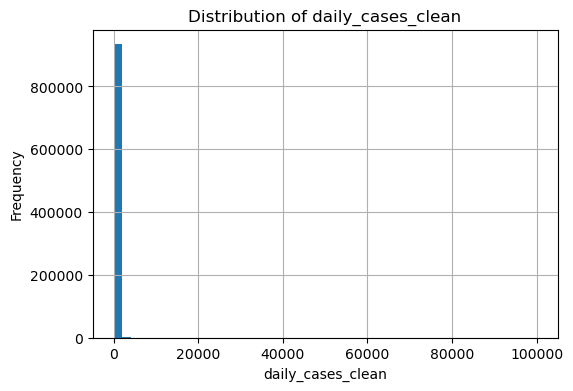

In [37]:
eda_utils.plot_distribution(df, 'daily_cases_clean')

### COVID-19 Cases by Day of Week

Caption:

Median case counts are compared across days of the week to identify systematic reporting patterns.


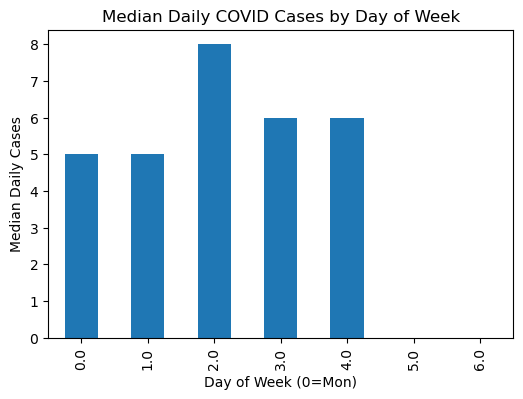

In [38]:
eda_utils.plot_day_of_week(df)

In [39]:
### Weekend vs Weekday Comparison

#Caption:

#Weekend reporting effects are explored by comparing case distributions between weekdays and weekends.

<Figure size 600x400 with 0 Axes>

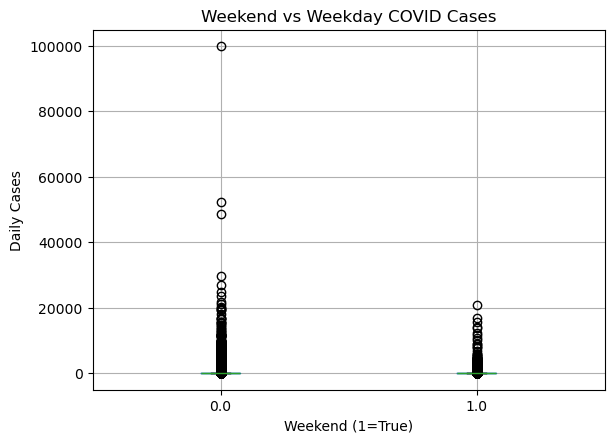

In [40]:
eda_utils.plot_weekend_box(df)

In [41]:
### Mobility and COVID-19 Case Relationships

#Caption:

#Relationships between mobility behavior and reported case counts are visualized.

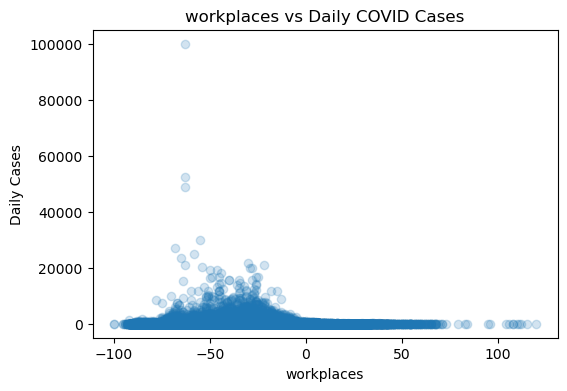

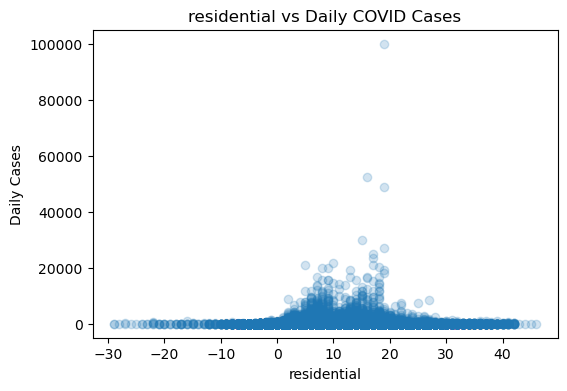

In [42]:
eda_utils.plot_relationship(df, 'workplaces')
eda_utils.plot_relationship(df, 'residential')

In [43]:
### Temporal Trends Over Time

#Caption:

#Time trends are examined using rolling averages to identify major COVID-19 waves.

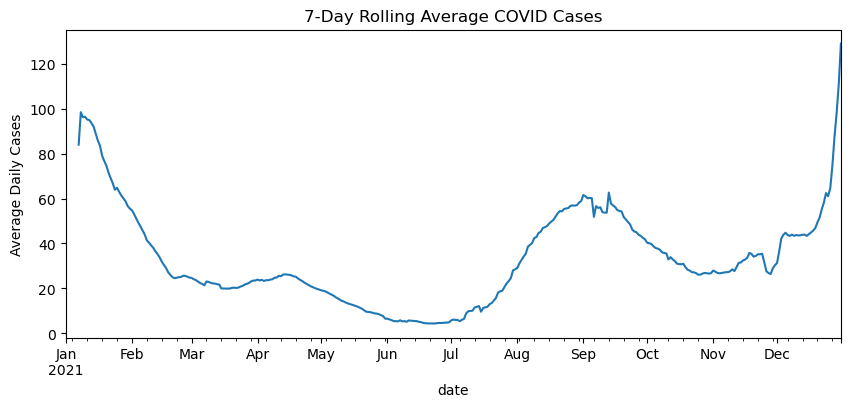

In [44]:
eda_utils.plot_time_trend(df)

## Ethics 

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

Our analysis uses publicly available, aggregated county-level COVID-19 case counts and mobility metrics. We do not recruit participants, interact with individuals, or collect new individual-level data, so informed consent is not required for our work. However, we acknowledge that mobility metrics originate from smartphone location signals and that many users may not fully understand downstream secondary uses, even when data is anonymized and aggregated.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

Mobility data can underrepresent people without smartphones or stable location services (for example older adults, low income communities, unhoused populations, and some rural areas). COVID-19 case counts also reflect testing access and reporting practices that vary by county and over time. We will interpret findings as population-level associations and avoid claims that assume equal measurement quality across all counties or groups.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

Our dataset is already aggregated to county-day level and does not include direct identifiers (names, addresses, device IDs). We will not attempt any re-identification or linkage to external individual-level datasets. We will also avoid presenting results as county rankings intended to label places as good or bad.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

Our results could be misused to blame specific regions or communities for COVID-19 spread or to justify punitive policy based on mobility patterns. We will present conclusions carefully, emphasizing that mobility is a proxy for many structural factors and that associations do not imply individual fault or causation. Where feasible, we will add contextual covariates (for example population, time controls, fixed effects) and include limitations that discourage stigmatizing interpretations.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

The data are public and aggregated, so the risk level is low, but we will still follow basic security practices: keep data in the course GitHub repo, avoid sharing raw data outside the team, and ensure devices/accounts used to access the repo are protected. We will not store any private keys or credentials in the repository.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

Because the dataset does not contain individual-level identifiers, individuals cannot be singled out or removed from our data. We rely on the data providers' governance and opt-out mechanisms (if any). Our project does not maintain user-level records.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

We will keep the dataset only as long as needed for the course and reproducibility of the final report. After the course, we can remove large raw data files from the repo while retaining derived results and code that do not contain sensitive information.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

Public health outcomes depend on factors not captured by mobility (healthcare access, workplace protections, housing density, local policy, and reporting practices). We will check our assumptions using public health context from reputable sources and discuss limitations so our results are not interpreted as purely behavioral explanations.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

We expect bias from uneven testing/reporting, time-varying policy changes, and demographic differences across counties. We will use appropriate controls (time effects, county fixed effects, lagged outcomes where relevant) and perform basic robustness checks (for example examining patterns across time periods) to reduce the chance of misleading conclusions.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

We will avoid causal wording and report results as associations. Visualizations will clearly label units and transformations, and we will include uncertainty or variability where possible. We will not cherry-pick dates or counties to support a preferred conclusion.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

No PII is present in the dataset and none will be introduced. We will only analyze and display aggregated county-level metrics.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

All preprocessing, analysis steps, and figure generation will be documented in notebooks/scripts in the repository. This supports reproducibility and makes it easier to identify issues if errors or data problems are later discovered.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

Mobility measures can correlate with socioeconomic status and occupation types. We will not use models for individual-level prediction, and we will interpret results as structural and measurement patterns rather than traits of any group.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

We are not building a high-stakes decision system, but we can still check whether model residuals or fit vary across counties (for example by population size or region). If large differences appear, we will report them as limitations and avoid overgeneralizing.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

We will use standard regression evaluation (for example goodness of fit and error measures) but will prioritize interpretability and stability over optimizing a single metric. We will compare multiple reasonable specifications to ensure conclusions are not driven by one modeling choice.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

We will use interpretable models (for example linear regression with coefficients) and explain findings in plain language. We will tie interpretations directly to observed variables and note when the data do not justify a stronger claim.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

Our report will include a limitations section emphasizing that associations are not causation, case reporting varies by testing/reporting practices, and mobility metrics may not represent all populations equally. We will explicitly discourage stigmatizing or punitive interpretations.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

We are not deploying a model in production. Still, we will sanity-check outputs (for example extreme spikes, missing dates, or inconsistent values) and document cleaning decisions to reduce errors in the final report.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

Because this is a course research analysis and not a deployed system, formal redress is not applicable. The main risk is misinterpretation, so we mitigate harm through careful framing, avoiding causal claims, and clearly stating limitations and appropriate uses.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

Not applicable because we are not deploying a production model. If issues are found, we can update or remove analyses in the repository and clearly note changes.

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

Unintended use is possible if results are used to justify surveillance or punitive restrictions targeted at particular counties. We will avoid producing county rankings meant for enforcement decisions, use neutral language, and emphasize that mobility is an imperfect proxy that should not be used for punitive action.


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them